준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.5.1
pandas: 3.0.3
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


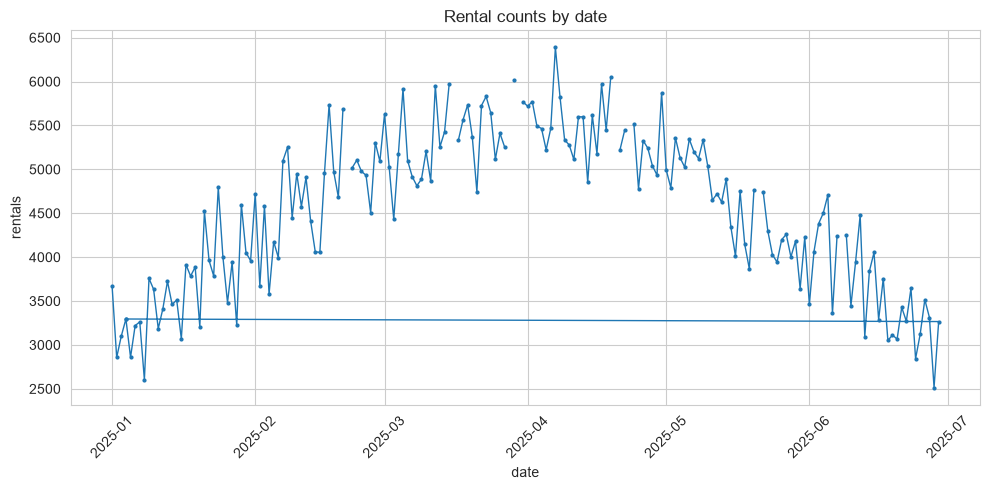

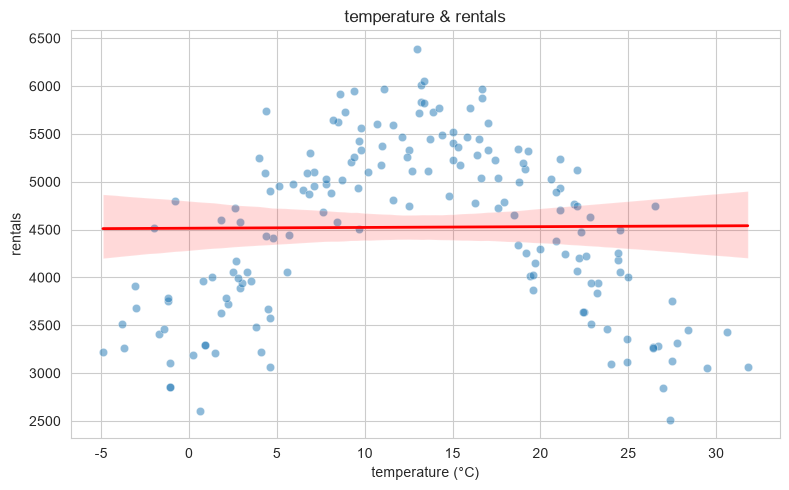

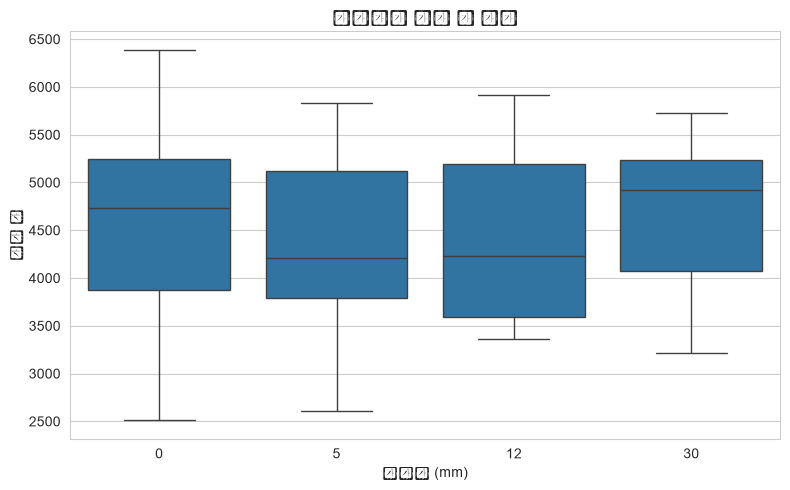

In [4]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 설치 확인 + 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
!pip install numpy pd matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

bike.shape
bike.info()
bike.describe()
bike.isnull().sum()
bike["station_area"].unique()

# ─────────────────────────────────────────────
# [추이] 날짜별 대여 수 — 봄~여름 증가하는 계절성 확인
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(bike["date"], bike["rentals"], marker="o", markersize=2, linewidth=1)
plt.title("Rental counts by date")
plt.xlabel("date")
plt.ylabel("rentals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# [관계] 기온과 대여 수 — 관계 확인
# ─────────────────────────────────────────────
sample = bike[
    (bike["avg_temp"] < 50) &          # 정상 기온 범위만 (한국 기준 여유있게)
    (bike["rentals"].notna())          # 대여 수 결측 제외
]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="avg_temp", y="rentals", alpha=0.5)
sns.regplot(data=sample, x="avg_temp", y="rentals",
            scatter=False, color="red", line_kws={"linewidth": 2})
plt.title("temperature & rentals")
plt.xlabel("temperature (°C)")
plt.ylabel("rentals")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# [관계] 강수량과 대여 수 — 관계 확인
# ─────────────────────────────────────────────
# ─────────────────────────────────────────────
# [관계] 강수량과 대여 수 — 비가 오면 대여가 줄어들까?
# ─────────────────────────────────────────────
sample = bike[bike["rentals"].notna()]   # 결측치 제외

plt.figure(figsize=(8, 5))
sns.boxplot(data=sample, x="rainfall", y="rentals")
plt.title("강수량별 대여 수 분포")
plt.xlabel("강수량 (mm)")
plt.ylabel("대여 수")
plt.tight_layout()
plt.show()